In [1]:
import numpy as np
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import ticker
from scipy.optimize import curve_fit
from pylab import *
from scipy import ndimage
from matplotlib.colors import LinearSegmentedColormap
from functools import reduce
import operator

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 16
    })

In [5]:
def convert_density(g_per_cm3):
    # Constants
    c_squared = 9e16  # Speed of light squared in m^2/s^2
    joule_to_mev = 6.242e12  # 1 Joule = 6.242e12 MeV
    m3_to_fm3 = 1e45  # 1 m^3 = 10^45 fm^3
    
    # Convert g/cm^3 to kg/m^3
    kg_per_m3 = g_per_cm3 * 1e3
    
    # Energy density in J/m^3
    energy_density_joule_per_m3 = kg_per_m3 * c_squared
    
    # Convert J/m^3 to MeV/m^3
    energy_density_mev_per_m3 = energy_density_joule_per_m3 * joule_to_mev
    
    # Convert MeV/m^3 to MeV/fm^3
    energy_density_mev_per_fm3 = energy_density_mev_per_m3 / m3_to_fm3
    
    return energy_density_mev_per_fm3

In [13]:
def convert_pressure(dyne_per_cm2):
    # Constants
    dyne_per_cm2_to_pascal = 0.1  # 1 dyne/cm^2 = 0.1 Pa
    joule_to_mev = 6.242e12  # 1 Joule = 6.242e12 MeV
    m3_to_fm3 = 1e45  # 1 m^3 = 10^45 fm^3
    
    # Convert dyne/cm^2 to Pascals (N/m^2)
    pressure_pa = dyne_per_cm2 * dyne_per_cm2_to_pascal
    
    # Convert Pa to J/m^3 (since pressure and energy density have same units)
    energy_density_joule_per_m3 = pressure_pa
    
    # Convert J/m^3 to MeV/m^3
    energy_density_mev_per_m3 = energy_density_joule_per_m3 * joule_to_mev
    
    # Convert MeV/m^3 to MeV/fm^3
    energy_density_mev_per_fm3 = energy_density_mev_per_m3 / m3_to_fm3
    
    return energy_density_mev_per_fm3

In [81]:
# Load in pressure density curves 
press_dens_GW170817_physics = np.load('eos_confidence_intervals_GW170817_physics.npz')
print(press_dens.files)
rho_GW170817_physics  = press_dens_GW170817_physics['rho']
rho_GW170817_physics = rho_GW170817_physics*1e-3 # Convert to cgs
press_low_GW170817_physics = 10**(press_dens_GW170817_physics['bns_logp_CIlow']+1.)
press_high_GW170817_physics = 10**(press_dens_GW170817_physics['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_GW170817_physics = rho_GW170817_physics/1.7827e12 
# Convert to MeV/fm^3
press_low_GW170817_physics= press_low_GW170817_physics/1.6022e33
press_high_GW170817_physics = press_high_GW170817_physics/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

['rho', 'bns_logp_CIlow', 'bns_logp_CIup', 'bns_logp_med', 'bns_prior_low', 'bns_prior_high', 'bns_prior_med']


In [82]:
# Load in the prior 
# Load in pressure density curves 
press_dens_physics_prior = np.load('eos_confidence_intervals_BNS_prior.npz')
print(press_dens.files)
rho_physics_prior  = press_dens_physics_prior['rho']
rho_physics_prior = rho_physics_prior*1e-3 # Convert to cgs
press_low_physics_prior = 10**(press_dens_physics_prior['bns_logp_CIlow']+1.)
press_high_physics_prior = 10**(press_dens_physics_prior['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_physics_prior = rho_physics_prior/1.7827e12 
# Convert to MeV/fm^3
press_low_physics_prior= press_low_physics_prior/1.6022e33
press_high_physics_prior = press_high_physics_prior/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

['rho', 'bns_logp_CIlow', 'bns_logp_CIup', 'bns_logp_med', 'bns_prior_low', 'bns_prior_high', 'bns_prior_med']


In [83]:
# Load in the prior 
# Load in pressure density curves 
press_dens_uniform = np.load('eos_confidence_intervals_uniform.npz')
print(press_dens.files)
rho_uniform  = press_dens_uniform['rho']
rho_uniform = rho_uniform*1e-3 # Convert to cgs
press_low_uniform = 10**(press_dens_uniform['bns_logp_CIlow']+1.)
press_high_uniform = 10**(press_dens_uniform['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_uniform = rho_uniform/1.7827e12 
# Convert to MeV/fm^3
press_low_uniform= press_low_uniform/1.6022e33
press_high_uniform = press_high_uniform/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

['rho', 'bns_logp_CIlow', 'bns_logp_CIup', 'bns_logp_med', 'bns_prior_low', 'bns_prior_high', 'bns_prior_med']


In [106]:
# Load in the prior 
# Load in pressure density curves 
press_dens_uniform_prior = np.load('eos_confidence_intervals_uniform_prior.npz')
print(press_dens.files)
rho_uniform_prior  = press_dens_uniform_prior['rho']
rho_uniform_prior = rho_uniform_prior*1e-3 # Convert to cgs
press_low_uniform_prior = 10**(press_dens_uniform_prior['bns_logp_CIlow']+1.)
press_high_uniform_prior = 10**(press_dens_uniform_prior['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_uniform_prior = rho_uniform_prior/1.7827e12 
# Convert to MeV/fm^3
press_low_uniform_prior= press_low_uniform_prior/1.6022e33
press_high_uniform_prior = press_high_uniform_prior/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

['rho', 'bns_logp_CIlow', 'bns_logp_CIup', 'bns_logp_med', 'bns_prior_low', 'bns_prior_high', 'bns_prior_med']


[171.33657061262716, 3.7790377427582174]
[171.33657061262716, 2.0832375804296883]


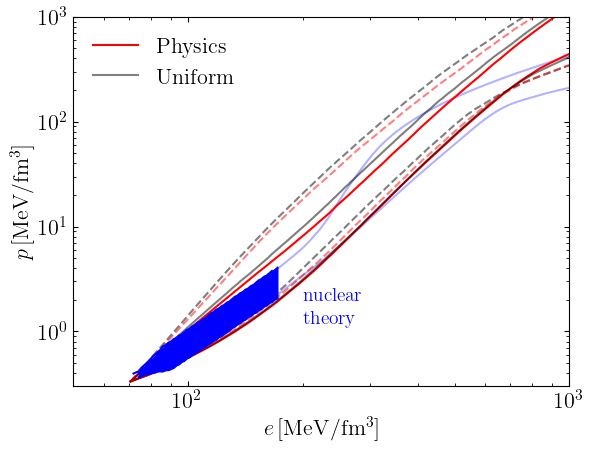

In [111]:

# CET eos
CET=np.loadtxt("CET.txt")

# pQCD band
pQCD=np.loadtxt("pQCD.txt")


# outer contours
constraint1=np.loadtxt("cloudEOS2p0.txt")
constraint2=np.loadtxt("cloudEOS2p18.txt")
constraint3=np.loadtxt("cloudEOS2p35.txt")
constraint4=np.loadtxt("cloudEOS2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1peMtov2p0.dat")
cont2=np.loadtxt("cont0p1peMtov2p18.dat")
cont3=np.loadtxt("cont0p1peMtov2p35.dat")
cont4=np.loadtxt("cont0p1peMtov2p52.dat")


# generating a figure
fig, ax=plt.subplots(sharex=True,facecolor='white',dpi=100)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([50,1*10**3])
ax.set_ylim([3e-1,10**3])
#ax.grid(color="gray", linestyle="dashed", linewidth=0.5)
ax.tick_params(which='major', direction='in',top="true",right="true")
ax.tick_params(which='minor', direction='in',top="true",right="true")
plt.xlabel(r'$e\,\rm [MeV/fm^3]$', fontsize = 16)
plt.ylabel(r'$p\,\rm [MeV/fm^3]$',fontsize =  16)


# outer contours
# Mtov>2.0Msun
#plt.plot(10**constraint1[:,0],10**constraint1[:,1], color = "blue"  , linestyle = "solid",zorder=1, alpha=0.3)
#plt.plot(10**constraint1[:,2],10**constraint1[:,3], color = "blue"  , linestyle = "solid",zorder=1, alpha=0.3)
plt.plot(10**cont1[:,0],10**cont1[:,1],             color = "blue"  , linestyle = "solid",zorder=1,alpha=0.3)
plt.plot(10**cont1[:,0],10**cont1[:,2],             color = "blue"  , linestyle = "solid",zorder=1,alpha=0.3)
#label=r"$M_{\rm TOV}\geq 2.0\,M_\odot$"
# # Mtov>2.18Msun
# plt.plot(10**constraint2[:,0],10**constraint2[:,1], color = "black", linestyle = "solid",zorder=1, alpha=0.8)
# plt.plot(10**constraint2[:,2],10**constraint2[:,3], color = "black", linestyle = "solid",zorder=1, alpha=0.8,label=r"$100\%$")
# plt.plot(10**cont2[:,0],10**cont2[:,1],             color = "black" , linestyle = "dashed",zorder=3,alpha=0.8)
# plt.plot(10**cont2[:,0],10**cont2[:,2],             color = "black" , linestyle = "dashed",zorder=3,alpha=0.8,label=r"$95\%$")

# # Mtov>2.35Msun
# plt.plot(10**constraint3[:,0],10**constraint3[:,1], color = "orange", linestyle = "solid",zorder=1, alpha=0.2)
# plt.plot(10**constraint3[:,2],10**constraint3[:,3], color = "orange", linestyle = "solid",zorder=1, alpha=0.2)
# plt.plot(10**cont3[:,0],10**cont3[:,1],             color = "orange", linestyle = "solid",zorder=1)
# plt.plot(10**cont3[:,0],10**cont3[:,2],             color = "orange", linestyle = "solid",zorder=1,label=r"$M_{\rm TOV}\geq 2.35\,M_\odot$")

# # Mtov>2.52Msun
# plt.plot(10**constraint4[:,0],10**constraint4[:,1], color = "red"   , linestyle = "solid",zorder=1, alpha=0.3)
# plt.plot(10**constraint4[:,2],10**constraint4[:,3], color = "red"   , linestyle = "solid",zorder=1, alpha=0.3)
# plt.plot(10**cont4[:,0],10**cont4[:,1],             color = "red"   , linestyle = "solid",zorder=1)
# plt.plot(10**cont4[:,0],10**cont4[:,2],             color = "red"   , linestyle = "solid",zorder=1,label=r"$M_{\rm TOV}\geq 2.52\,M_\odot$")

# CET band
ax.plot(10**CET[:,0],10**CET[:,1], color = "blue", linestyle = "solid",zorder=5)
ax.plot(10**CET[:,2],10**CET[:,3], color = "blue", linestyle = "solid",zorder=5)
ax.fill_between(10**CET[:,0],10**CET[:,1],1.1*10**CET[:,3], color = "blue" ,zorder=5)
ax.plot(10**CET[:,0],10**CET[:,1], color = "blue" ,zorder=5,linewidth=0.5)
ax.plot(10**CET[:,0],10**CET[:,3], color = "blue" ,zorder=5,linewidth=0.5)
print([10**CET[-1,0],10**CET[-1,3]])
print([10**CET[-1,0],10**CET[-1,1]])

# # pQCD band
# ax.plot(10**pQCD[:,0],10**pQCD[:,1], color = "green", linestyle =  "solid",zorder=2 )
# ax.plot(10**pQCD[:,2], 10**pQCD[:,3],  color = "green", linestyle = "solid",zorder=2)
# ax.fill_between(10**pQCD[:,0],1.1*10**pQCD[:,1],1.15*10**pQCD[:,3], color = "green",zorder=2)

plt.text(200, 2.0 ,r'$\rm nuclear$', fontsize = 14, color="blue")
plt.text(200, 1.2 ,r'$\rm theory$', fontsize = 14, color="blue")
#plt.text(18000, 1600 ,r'$\rm pQCD$', fontsize = 14,color="green")

#plt.plot(eng_dens,press_low,color='purple')
#plt.plot(eng_dens,press_high,color='purple')
# plt.fill_between(eng_dens_GW170817_physics, press_low_GW170817_physics, press_high_GW170817_physics, 
#                        color='red', alpha=0.5, label=r'$\rm GW170817$', zorder=2)
plt.plot(eng_dens_GW170817_physics, press_low_GW170817_physics,color='red',label=r'$\rm Physics$',zorder=2)
plt.plot(eng_dens_GW170817_physics, press_high_GW170817_physics,color='red',zorder=2)

plt.plot(eng_dens_uniform, press_low_uniform, 
                     color='black', alpha=0.5, label=r'$\rm Uniform$', zorder=2)
plt.plot(eng_dens_uniform, press_high_uniform,color='black', alpha=0.5, zorder=2)
plt.plot(eng_dens_uniform_prior, press_low_uniform_prior, 
                     color='black', alpha=0.5, zorder=2,linestyle='dashed')
plt.plot(eng_dens_uniform_prior, press_high_uniform_prior,color='black', alpha=0.5, zorder=2,linestyle='dashed')
#plt.fill_between(eng_dens_uniform, press_low_uniform, press_high_uniform, 
#                       color='black', alpha=0.5, label=r'$\rm GW170817$', zorder=2)

plt.plot(eng_dens_physics_prior, press_low_physics_prior, 
                       color='red', alpha=0.5,linestyle='dashed')
plt.plot(eng_dens_physics_prior,press_high_physics_prior, 
                       color='red', alpha=0.5,linestyle='dashed')
plt.legend(loc="upper left",fontsize=16,frameon=False)
plt.savefig('press_dens_GW170817_w_prior.pdf',dpi=500)

In [113]:
# Now we repeat for GW190425 
# Load in pressure density curves 
press_dens_GW190425_BNS_physics = np.load('eos_confidence_intervals_GW190425_BNS_physics.npz')
print(press_dens.files)
rho_GW190425_BNS_physics  = press_dens_GW190425_BNS_physics['rho']
rho_GW190425_BNS_physics = rho_GW190425_BNS_physics*1e-3 # Convert to cgs
press_low_GW190425_BNS_physics = 10**(press_dens_GW190425_BNS_physics['bns_logp_CIlow']+1.)
press_high_GW190425_BNS_physics = 10**(press_dens_GW190425_BNS_physics['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_GW190425_BNS_physics = rho_GW190425_BNS_physics/1.7827e12 
# Convert to MeV/fm^3
press_low_GW190425_BNS_physics= press_low_GW190425_BNS_physics/1.6022e33
press_high_GW190425_BNS_physics = press_high_GW190425_BNS_physics/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)


['rho', 'bns_logp_CIlow', 'bns_logp_CIup', 'bns_logp_med', 'bns_prior_low', 'bns_prior_high', 'bns_prior_med']


In [118]:
# Now we repeat for GW190425 
# Load in pressure density curves 
press_dens_GW190425_NSBH_physics = np.load('eos_confidence_intervals_GW190425_NSBH_physics.npz')
print(press_dens.files)
rho_GW190425_NSBH_physics  = press_dens_GW190425_NSBH_physics['rho']
rho_GW190425_NSBH_physics = rho_GW190425_NSBH_physics*1e-3 # Convert to cgs
press_low_GW190425_NSBH_physics = 10**(press_dens_GW190425_NSBH_physics['bns_logp_CIlow']+1.)
press_high_GW190425_NSBH_physics = 10**(press_dens_GW190425_NSBH_physics['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_GW190425_NSBH_physics = rho_GW190425_NSBH_physics/1.7827e12 
# Convert to MeV/fm^3
press_low_GW190425_NSBH_physics= press_low_GW190425_NSBH_physics/1.6022e33
press_high_GW190425_NSBH_physics = press_high_GW190425_NSBH_physics/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

['rho', 'bns_logp_CIlow', 'bns_logp_CIup', 'bns_logp_med', 'bns_prior_low', 'bns_prior_high', 'bns_prior_med']


In [123]:
# Load in the NSBH prior 
# Load in the prior 
# Load in pressure density curves 
press_dens_physics_prior_NSBH = np.load('eos_confidence_intervals_NSBH_prior.npz')
rho_physics_prior_NSBH  = press_dens_physics_prior_NSBH['rho']
rho_physics_prior_NSBH = rho_physics_prior_NSBH*1e-3 # Convert to cgs
press_low_physics_prior_NSBH = 10**(press_dens_physics_prior_NSBH['bns_logp_CIlow']+1.)
press_high_physics_prior_NSBH = 10**(press_dens_physics_prior_NSBH['bns_logp_CIup']+1.)

# Convert to MeV/fm^3
eng_dens_physics_prior_NSBH = rho_physics_prior_NSBH/1.7827e12 
# Convert to MeV/fm^3
press_low_physics_prior_NSBH= press_low_physics_prior_NSBH/1.6022e33
press_high_physics_prior_NSBH = press_high_physics_prior_NSBH/1.6022e33
#press_eng = convert_pressure(press_low)
#print(press_eng)
#print(eng_dens)

[171.33657061262716, 3.7790377427582174]
[171.33657061262716, 2.0832375804296883]


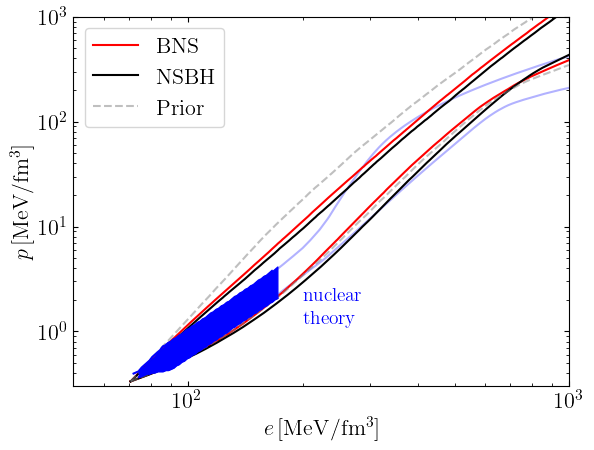

In [134]:
# generating a figure
fig, ax=plt.subplots(sharex=True,facecolor='white',dpi=100)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([50,1*10**3])
ax.set_ylim([3e-1,10**3])
#ax.grid(color="gray", linestyle="dashed", linewidth=0.5)
ax.tick_params(which='major', direction='in',top="true",right="true")
ax.tick_params(which='minor', direction='in',top="true",right="true")
plt.xlabel(r'$e\,\rm [MeV/fm^3]$', fontsize = 16)
plt.ylabel(r'$p\,\rm [MeV/fm^3]$',fontsize =  16)


#plt.plot(10**constraint1[:,0],10**constraint1[:,1], color = "blue"  , linestyle = "solid",zorder=1, alpha=0.3)
#plt.plot(10**constraint1[:,2],10**constraint1[:,3], color = "blue"  , linestyle = "solid",zorder=1, alpha=0.3)
plt.plot(10**cont1[:,0],10**cont1[:,1],             color = "blue"  , linestyle = "solid",zorder=1,alpha=0.3)
plt.plot(10**cont1[:,0],10**cont1[:,2],             color = "blue"  , linestyle = "solid",zorder=1,alpha=0.3)
ax.plot(10**CET[:,0],10**CET[:,1], color = "blue", linestyle = "solid",zorder=5)
ax.plot(10**CET[:,2],10**CET[:,3], color = "blue", linestyle = "solid",zorder=5)
ax.fill_between(10**CET[:,0],10**CET[:,1],1.1*10**CET[:,3], color = "blue" ,zorder=5)
ax.plot(10**CET[:,0],10**CET[:,1], color = "blue" ,zorder=5,linewidth=0.5)
ax.plot(10**CET[:,0],10**CET[:,3], color = "blue" ,zorder=5,linewidth=0.5)
print([10**CET[-1,0],10**CET[-1,3]])
print([10**CET[-1,0],10**CET[-1,1]])
plt.text(200, 2.0 ,r'$\rm nuclear$', fontsize = 14, color="blue")
plt.text(200, 1.2 ,r'$\rm theory$', fontsize = 14, color="blue")

plt.plot(eng_dens_GW190425_BNS_physics, press_low_GW190425_BNS_physics,color='red',label=r'$\rm BNS$',zorder=2)
plt.plot(eng_dens_GW190425_BNS_physics, press_high_GW190425_BNS_physics,color='red',zorder=2)
plt.plot(eng_dens_GW190425_NSBH_physics, press_low_GW190425_NSBH_physics,color='black',label=r'$\rm NSBH$',zorder=2)
plt.plot(eng_dens_GW190425_NSBH_physics, press_high_GW190425_NSBH_physics,color='black',zorder=2)

plt.plot(eng_dens_physics_prior, press_low_physics_prior, 
                       color='grey', alpha=0.5,linestyle='dashed')
plt.plot(eng_dens_physics_prior,press_high_physics_prior, 
                       color='grey', alpha=0.5,linestyle='dashed',label=r'$\rm Prior$')

#plt.plot(eng_dens_physics_prior_NSBH, press_low_physics_prior_NSBH, 
#                       color='grey', alpha=0.5,linestyle='dashed')
#plt.plot(eng_dens_physics_prior_NSBH,press_high_physics_prior_NSBH, 
#                       color='black', alpha=0.5,linestyle='dashed')
plt.legend()